In [1]:
from pathlib import Path
from scipy.io import loadmat
import sys
import os

# Robust path finding for data.mat
current_path = Path.cwd()
possible_data_paths = [
    current_path / 'data' / 'data.mat',
    current_path.parent / 'data' / 'data.mat',
    current_path.parent.parent / 'data' / 'data.mat',
    # Fallback absolute path
    Path('/home/luky/skola/KalmanNet-for-state-estimation/data/data.mat')
]

dataset_path = None
for p in possible_data_paths:
    if p.exists():
        dataset_path = p
        break

if dataset_path is None or not dataset_path.exists():
    print("Warning: data.mat not found automatically.")
    dataset_path = Path('data/data.mat')

print(f"Dataset path: {dataset_path}")

# Add project root to sys.path (2 levels up from debug/test)
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..', '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root added: {project_root}")

mat_data = loadmat(dataset_path)
print(mat_data.keys())


Dataset path: /home/luky/skola/KalmanNet-main/data/data.mat
Project root added: /home/luky/skola/KalmanNet-main
dict_keys(['__header__', '__version__', '__globals__', 'hB', 'souradniceGNSS', 'souradniceX', 'souradniceY', 'souradniceZ'])


In [2]:
import torch
import matplotlib.pyplot as plt
from utils import trainer
from utils import utils
from Systems import DynamicSystem
import Filters
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from scipy.io import loadmat
from scipy.interpolate import RegularGridInterpolator
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [3]:
mat_data = loadmat(dataset_path)

souradniceX_mapa = mat_data['souradniceX']
souradniceY_mapa = mat_data['souradniceY']
souradniceZ_mapa = mat_data['souradniceZ']
souradniceGNSS = mat_data['souradniceGNSS'] 
x_axis_unique = souradniceX_mapa[0, :]
y_axis_unique = souradniceY_mapa[:, 0]

print(f"Dimensions of 1D X axis: {x_axis_unique.shape}")
print(f"Dimensions of 1D Y axis: {y_axis_unique.shape}")
print(f"Dimensions of 2D elevation data Z: {souradniceZ_mapa.shape}")

terMap_interpolator = RegularGridInterpolator(
    (y_axis_unique, x_axis_unique),
    souradniceZ_mapa,
    bounds_error=False, 
    fill_value=np.nan
)

def terMap(px, py):
    # Query bilinear interpolation over the terrain map
    points_to_query = np.column_stack((py, px))
    return terMap_interpolator(points_to_query)

Dimensions of 1D X axis: (2500,)
Dimensions of 1D Y axis: (2500,)
Dimensions of 2D elevation data Z: (2500, 2500)


In [4]:
import torch
from Systems import DynamicSystemTAN

state_dim = 4
obs_dim = 3
dT = 1
q = 9.057863

F = torch.tensor([[1.0, 0.0, dT, 0.0],
                   [0.0, 1.0, 0.0, dT],
                   [0.0, 0.0, 1.0, 0.0],
                   [0.0, 0.0, 0.0, 1.0]])

Q = q* torch.tensor([[dT**3/3, 0.0, dT**2/2, 0.0],
                   [0.0, dT**3/3, 0.0, dT**2/2],
                   [dT**2/2, 0.0, dT, 0.0],
                   [0.0, dT**2/2, 0.0, dT]])
R = torch.tensor([[3.0**2, 0.0, 0.0],
                   [0.0, 1.0**2, 0.0],
                   [0.0, 0.0, 1.0**2]])

initial_velocity_np = souradniceGNSS[:2, 1] - souradniceGNSS[:2, 0]
# initial_velocity_np = torch.from_numpy()
initial_velocity = torch.from_numpy(np.array([0,0]))

initial_position = torch.from_numpy(souradniceGNSS[:2, 0])
x_0 = torch.cat([
    initial_position,
    initial_velocity
]).float()
print(x_0)

P_0 = torch.tensor([[25.0, 0.0, 0.0, 0.0],
                    [0.0, 25.0, 0.0, 0.0],
                    [0.0, 0.0, 0.5, 0.0],
                    [0.0, 0.0, 0.0, 0.5]])
import torch.nn.functional as func

def h_nl_differentiable(x: torch.Tensor, map_tensor, x_min, x_max, y_min, y_max) -> torch.Tensor:
    batch_size = x.shape[0]

    px = x[:, 0]
    py = x[:, 1]

    px_norm = 2.0 * (px - x_min) / (x_max - x_min) - 1.0
    py_norm = 2.0 * (py - y_min) / (y_max - y_min) - 1.0

    sampling_grid = torch.stack((px_norm, py_norm), dim=1).view(batch_size, 1, 1, 2)

    vyska_terenu_batch = func.grid_sample(
        map_tensor.expand(batch_size, -1, -1, -1),
        sampling_grid, 
        mode='bilinear', 
        padding_mode='border',
        align_corners=True
    )

    vyska_terenu = vyska_terenu_batch.view(batch_size)

    eps = 1e-12
    vx_w, vy_w = x[:, 2], x[:, 3]
    norm_v_w = torch.sqrt(vx_w**2 + vy_w**2).clamp(min=eps)
    cos_psi = vx_w / norm_v_w
    sin_psi = vy_w / norm_v_w

    vx_b = cos_psi * vx_w - sin_psi * vy_w 
    vy_b = sin_psi * vx_w + cos_psi * vy_w

    result = torch.stack([vyska_terenu, vx_b, vy_b], dim=1)

    return result

x_axis_unique = souradniceX_mapa[0, :]
y_axis_unique = souradniceY_mapa[:, 0]
terMap_tensor = torch.from_numpy(souradniceZ_mapa).float().unsqueeze(0).unsqueeze(0).to(device)
x_min, x_max = x_axis_unique.min(), x_axis_unique.max()
y_min, y_max = y_axis_unique.min(), y_axis_unique.max()

h_wrapper = lambda x: h_nl_differentiable(
    x, 
    map_tensor=terMap_tensor, 
    x_min=x_min, 
    x_max=x_max, 
    y_min=y_min, 
    y_max=y_max
)

system_model = DynamicSystemTAN(
    state_dim=state_dim,
    obs_dim=obs_dim,
    Q=Q.float(),
    R=R.float(),
    Ex0=x_0.float(),
    P0=P_0.float(),
    F=F.float(),
    h=h_wrapper,
    x_axis_unique=x_axis_unique, 
    y_axis_unique=y_axis_unique,
    device=device
)

tensor([1487547.1250, 6395520.5000,       0.0000,       0.0000])
INFO: DynamicSystemTAN inicializován s hranicemi mapy:
  X: [1476611.42, 1489541.47]
  Y: [6384032.63, 6400441.34]


In [5]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from utils import utils
import torch
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import os
import random
from copy import deepcopy
from utils import trainer 

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)


In [6]:
from state_NN_models import TAN

state_knet2 = TAN.StateKalmanNetTAN(
        system_model=system_model, 
        device=device,
        hidden_size_multiplier=4,       
        output_layer_multiplier=2,
        num_gru_layers=1,
        gru_hidden_dim_multiplier=4,
        use_log_modulus=True,
        use_terrain_grad=True      
).to(device)

# state_bkn = TAN.StateBayesianKalmanNetTAN(
#         system_model=system_model, 
#         device=device,
#         hidden_size_multiplier=4,       
#         output_layer_multiplier=2,
#         num_gru_layers=1,
#         gru_hidden_dim_multiplier=4,
#         init_max_dropout=0.3, # Skvělý výchozí bod, Beta-NLL si to teď už zkalibruje samo
#         init_min_dropout=0.1    
# ).to(device)
state_bkn = TAN.StateBayesianKalmanNetTAN(
        system_model=system_model, 
        device=device,
        hidden_size_multiplier=6,       
        output_layer_multiplier=2,
        num_gru_layers=1,
        gru_hidden_dim_multiplier=4,
        init_max_dropout=0.3, 
        init_min_dropout=0.1,
        use_log_modulus=True,
        use_terrain_grad=True    
).to(device)

import os
import torch

WEIGHTS_DIR = 'weights'

KNET_FILENAME = 'knet_curriculum_model_outperformed_UKF-latest.pth' #best_MSE_KalmanNet_linear_trajectory
# BKN_FILENAME = 'best_mse_bknet_with_terrain_grad-latest.pth'  
# BKN_FILENAME = 'test_bknet_with_terrain_grad.pth'
# BKN_FILENAME = 'test_bknet_with_terrain_grad_fine_tuned.pth'
BKN_FILENAME = 'full-best_mse_bknet_with_terrain_grad-latest.pth'
def load_pretrained_weights(model, filename, model_name):
    filepath = os.path.join(WEIGHTS_DIR, filename)

    try:

        checkpoint = torch.load(filepath, map_location=device)
        
        if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
            state_dict = checkpoint['model_state_dict']
        elif isinstance(checkpoint, dict) and 'state_dict' in checkpoint:
            state_dict = checkpoint['state_dict']
        else:
            state_dict = checkpoint

        model.load_state_dict(state_dict)
        
        model.eval()
        
        
    except Exception as e:
        print(f"❌ Error: {e}")


load_pretrained_weights(state_knet2, KNET_FILENAME, "State KalmanNet")

load_pretrained_weights(state_bkn, BKN_FILENAME, "State BKN")


DNN initialized WITH terrain slope (+2 features)
DEBUG: Layer 'output_final_linear.0' initialized near zero (Start K=0).
Bayesian DNN initialized WITH terrain slope (+2 features)


In [7]:
def print_model_parameters(model, model_name):
    total_params = sum(p.numel() for p in model.parameters())
    
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"📊 {model_name}:")
    print(f"   - All Parameter: {total_params:,}".replace(',', ' '))
    print(f"   - Trainable params: {trainable_params:,}".replace(',', ' '))
    print("-" * 40)
print_model_parameters(state_knet2, "State KalmanNet")
print_model_parameters(state_bkn, "State Bayesian KalmanNet (BKN)")

📊 State KalmanNet:
   - All Parameter: 104 332
   - Trainable params: 104 332
----------------------------------------
📊 State Bayesian KalmanNet (BKN):
   - All Parameter: 139 870
   - Trainable params: 139 870
----------------------------------------


# Test on synthetic trajektory

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.30it/s]


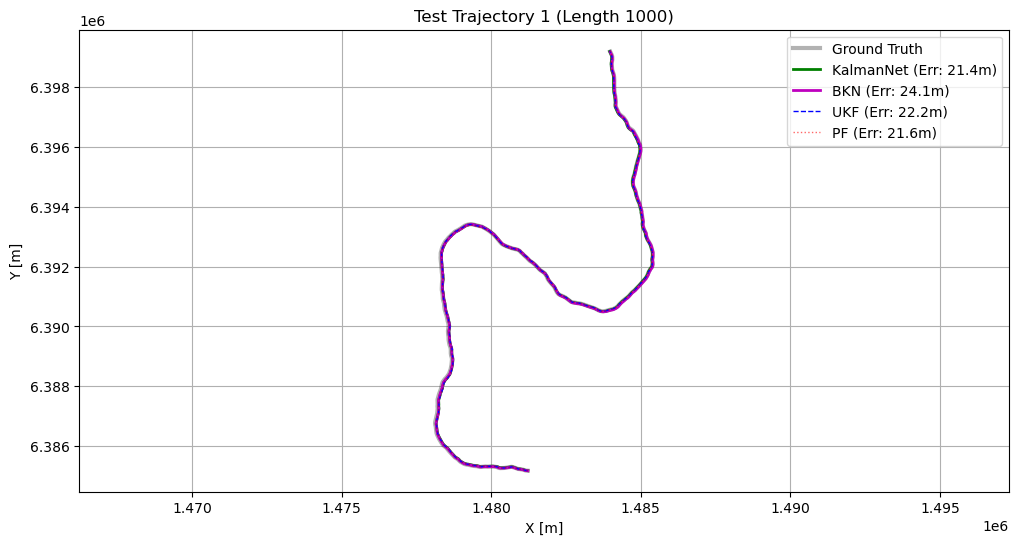

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.47it/s]]


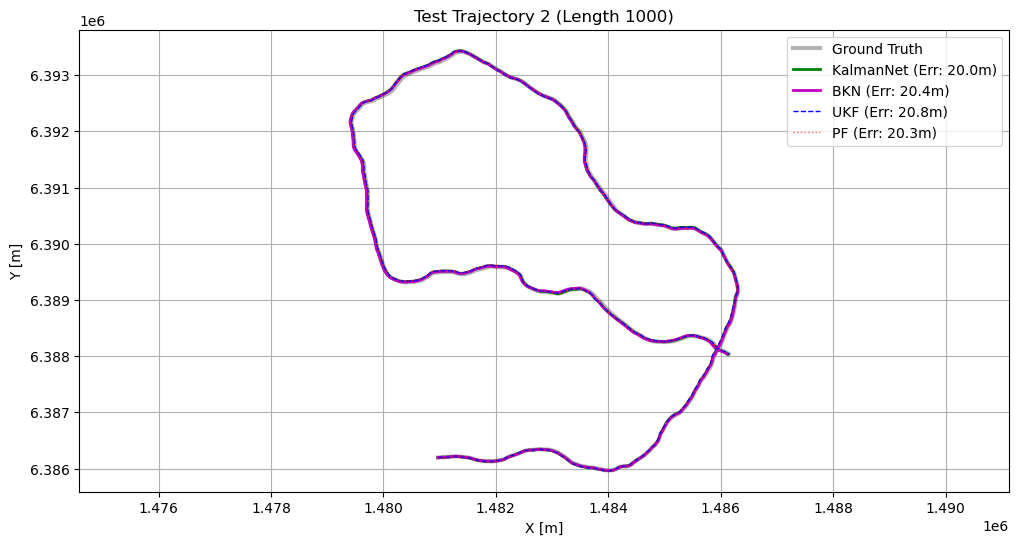

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.51it/s]]


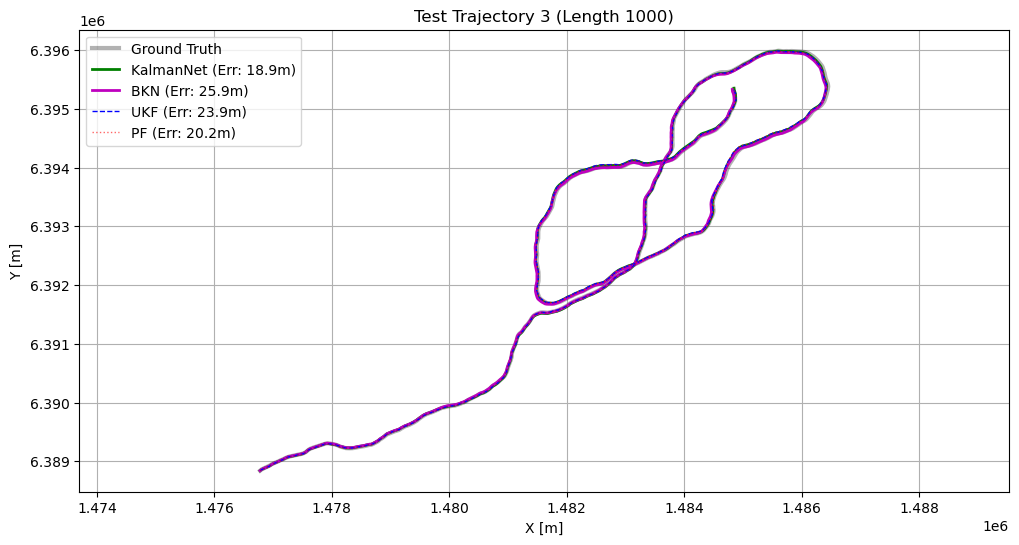

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.38it/s]]


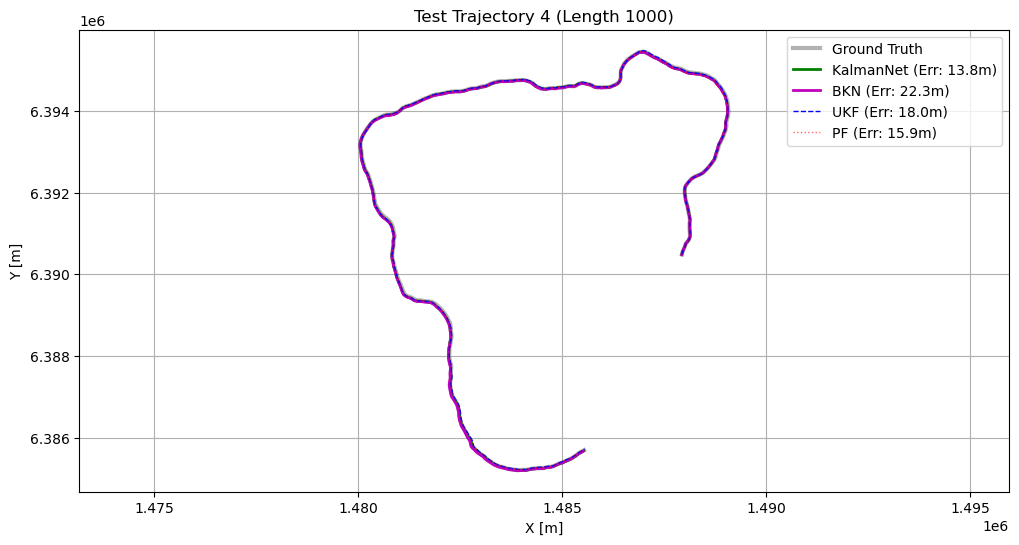

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.44it/s]]


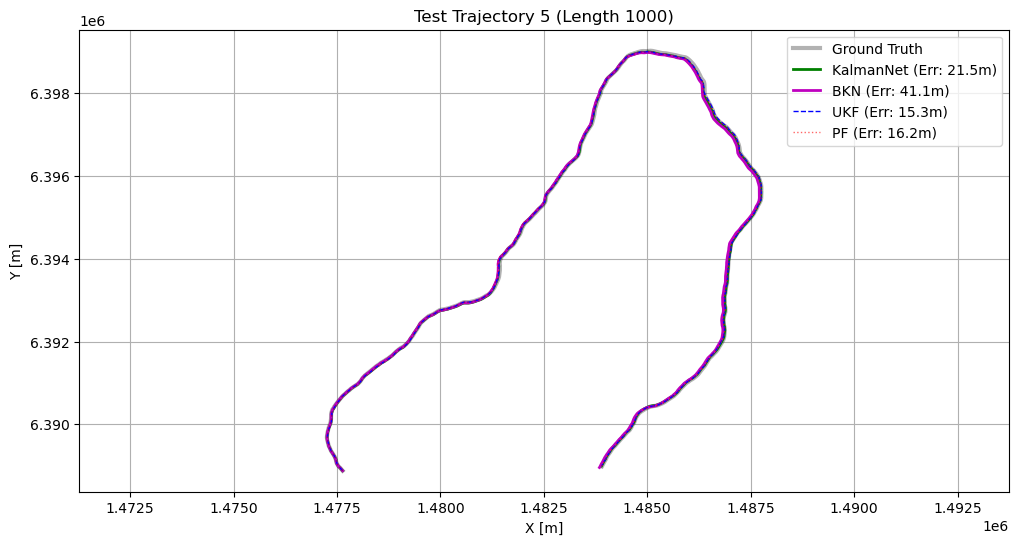

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.39it/s]]


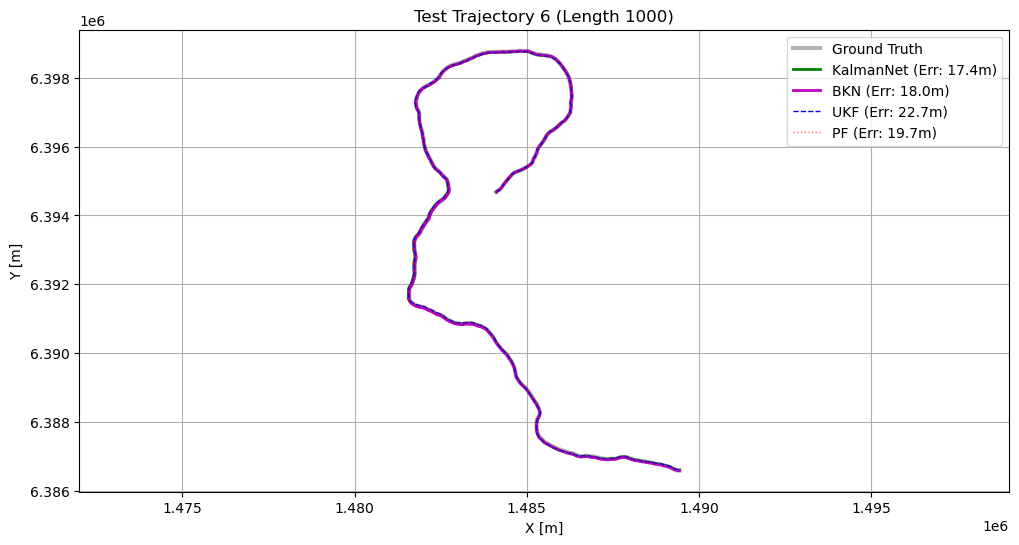

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.42it/s]]


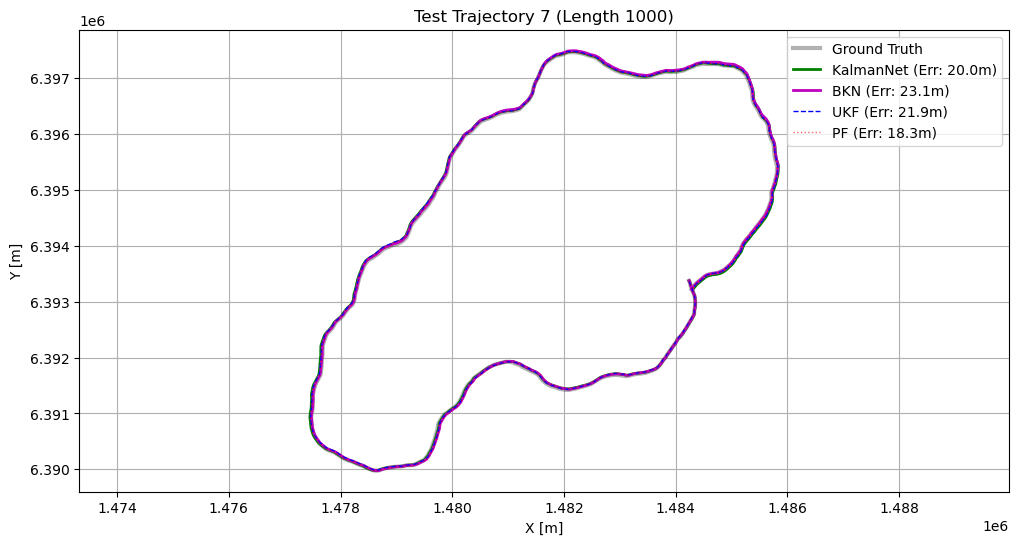

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.36it/s]]


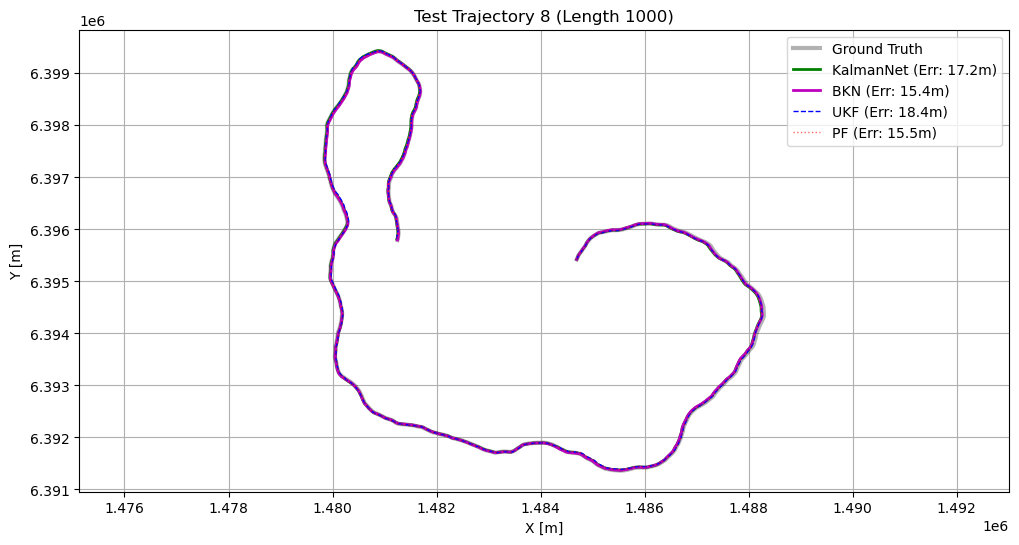

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.33it/s]]


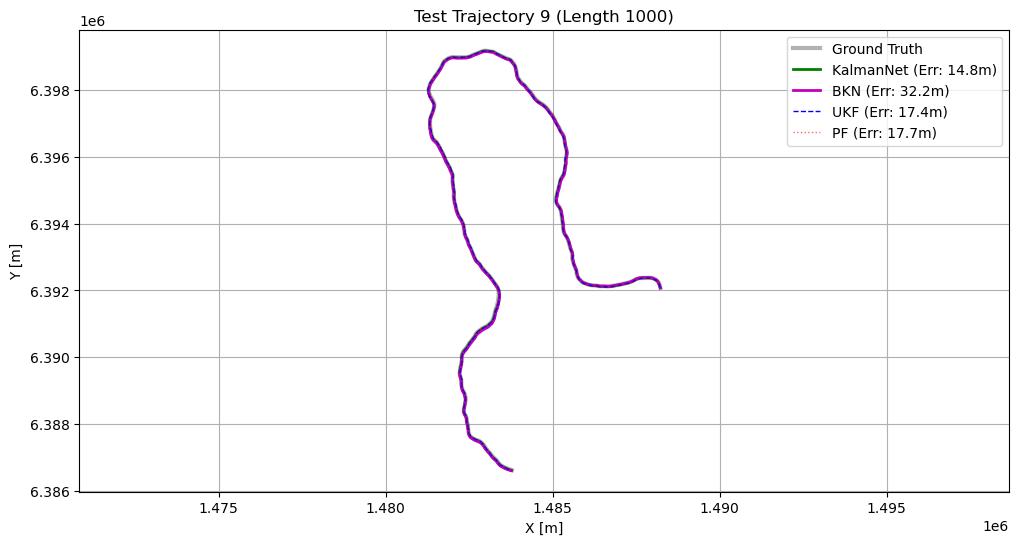

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.45it/s]]


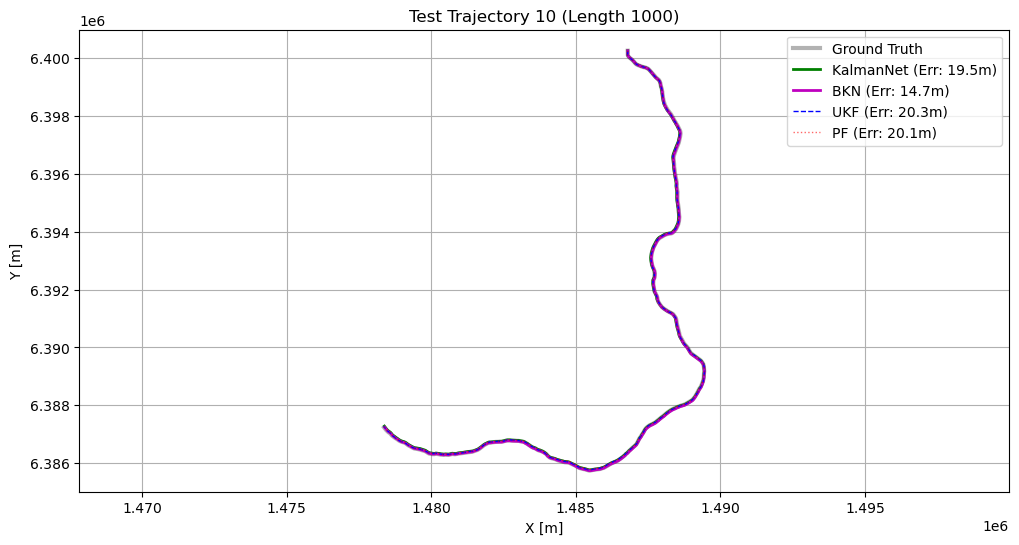

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.44it/s]t]


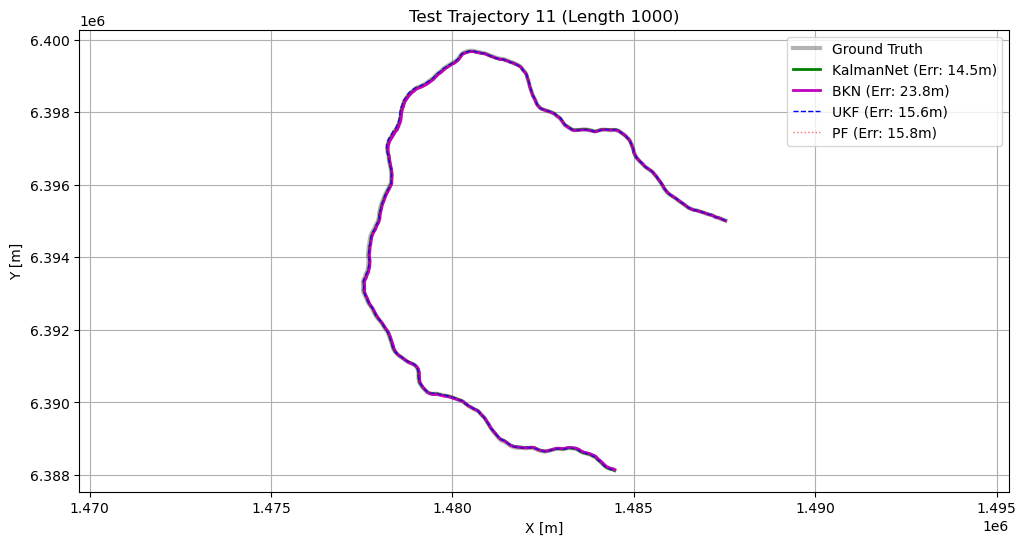

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.42it/s]t]


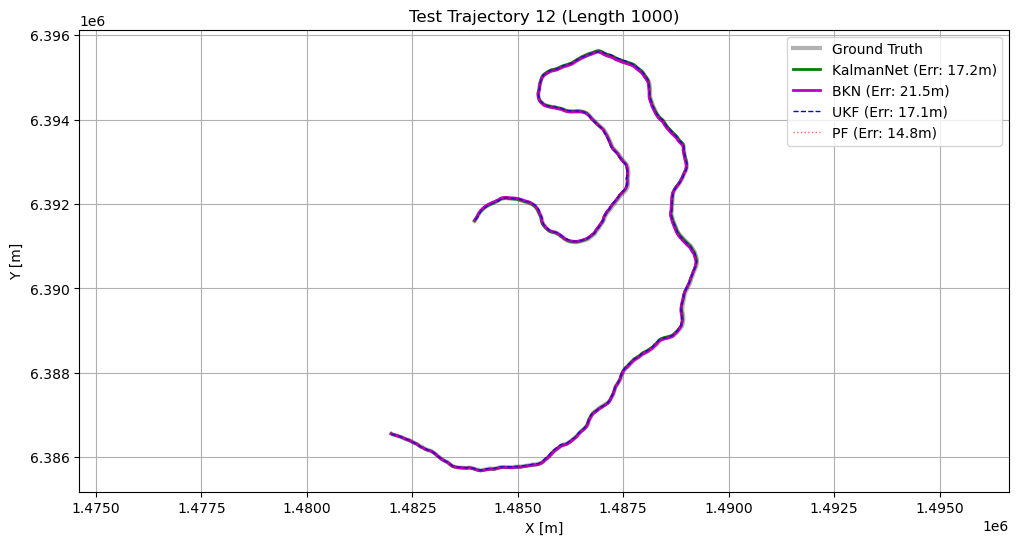

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.40it/s]t]


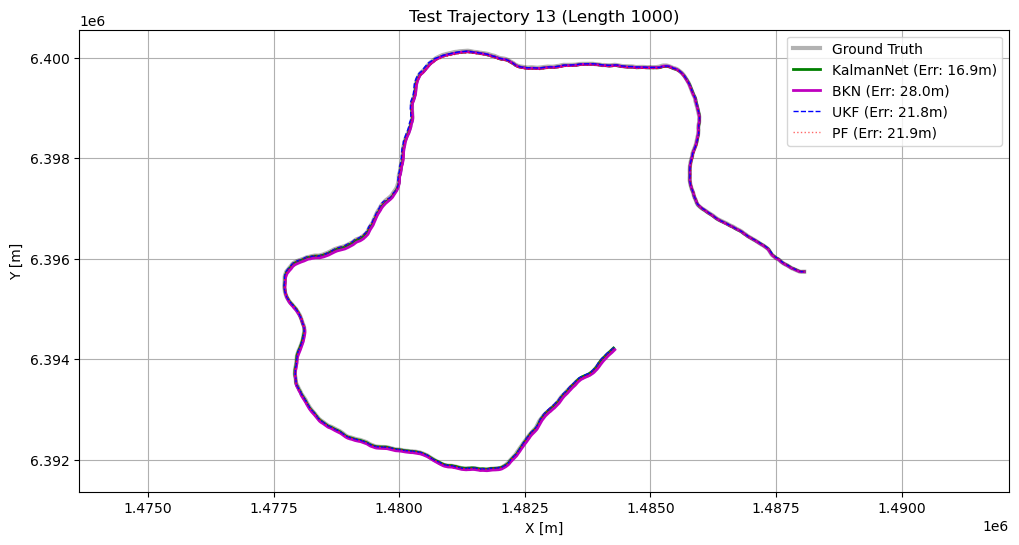

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.45it/s]t]


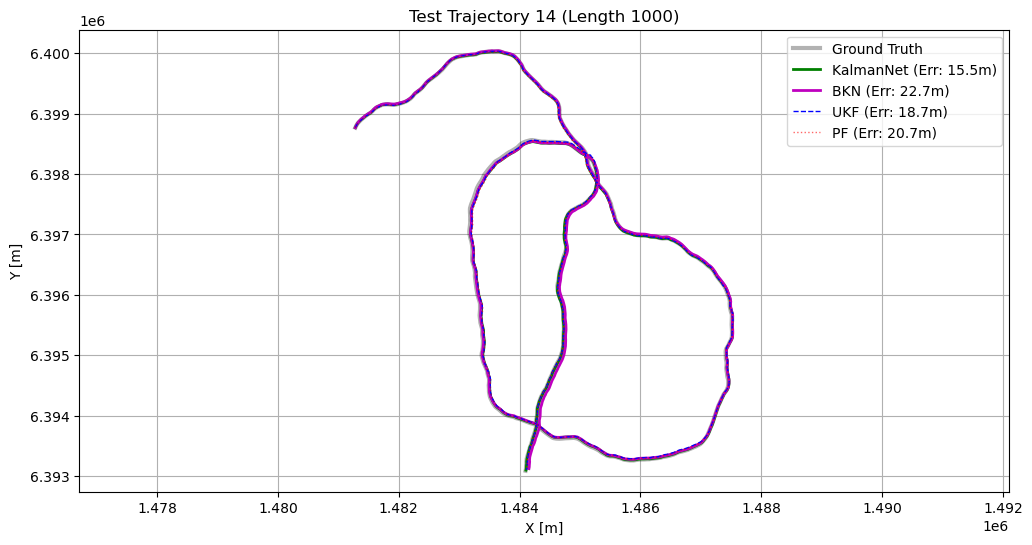

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.38it/s]t]


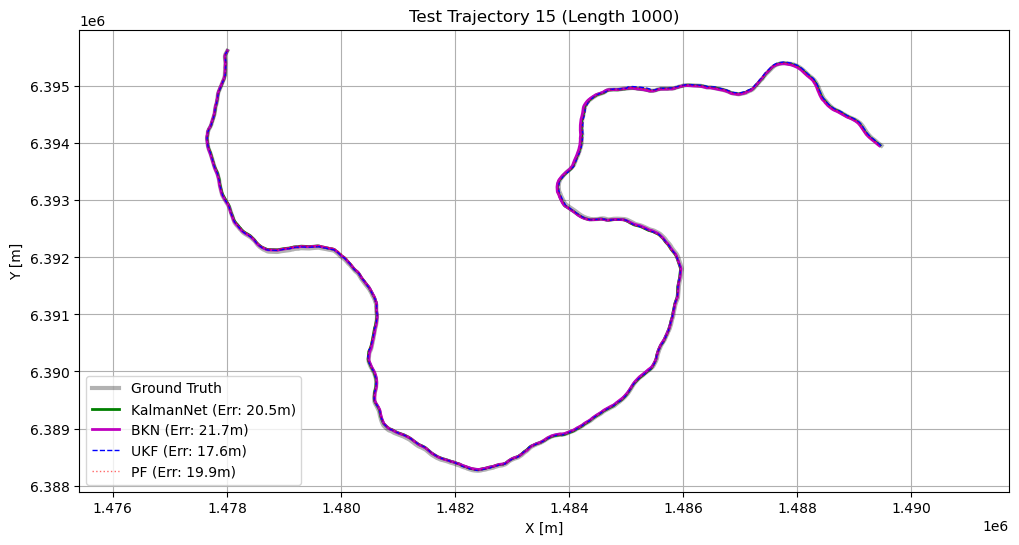

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.44it/s]t]


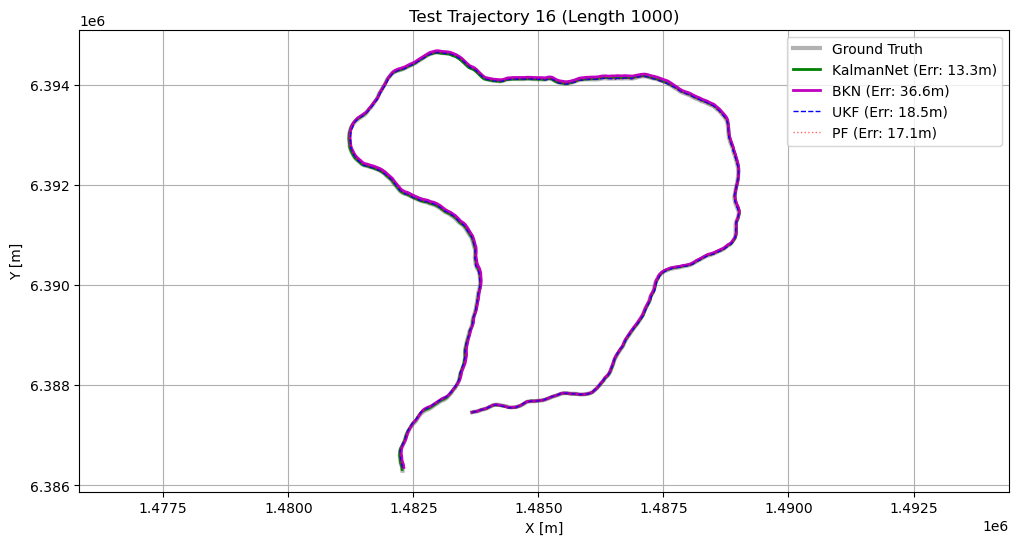

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.43it/s]t]


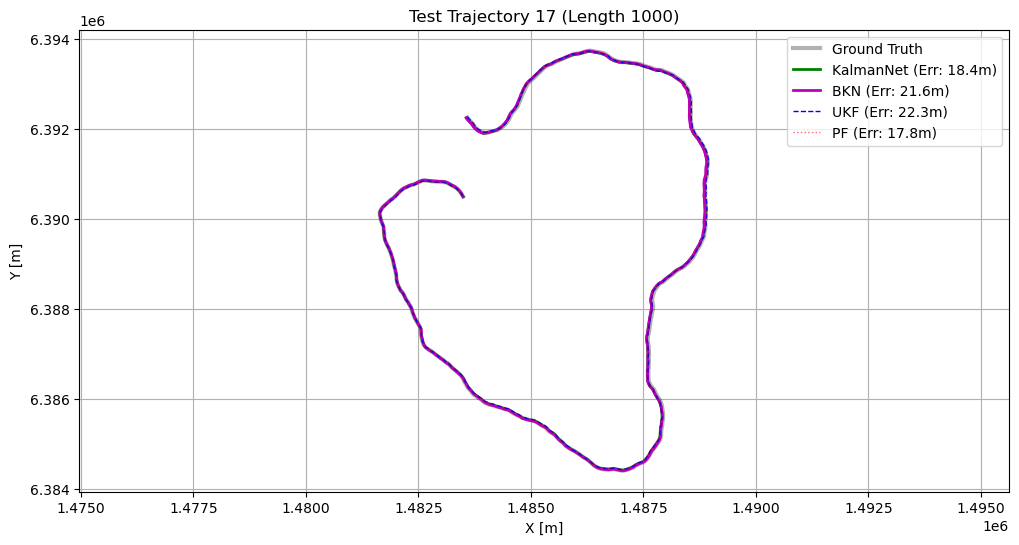

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.45it/s]t]


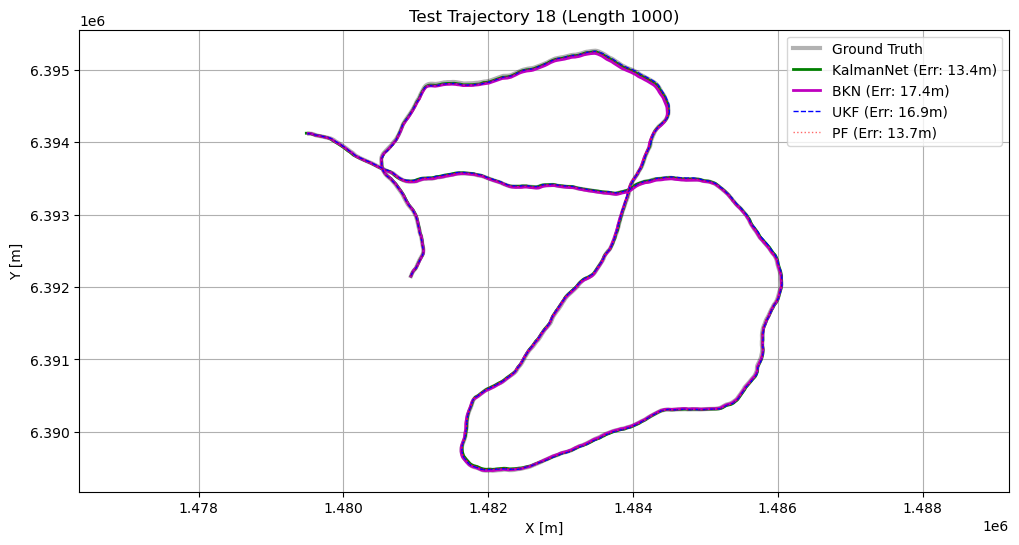

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.37it/s]t]


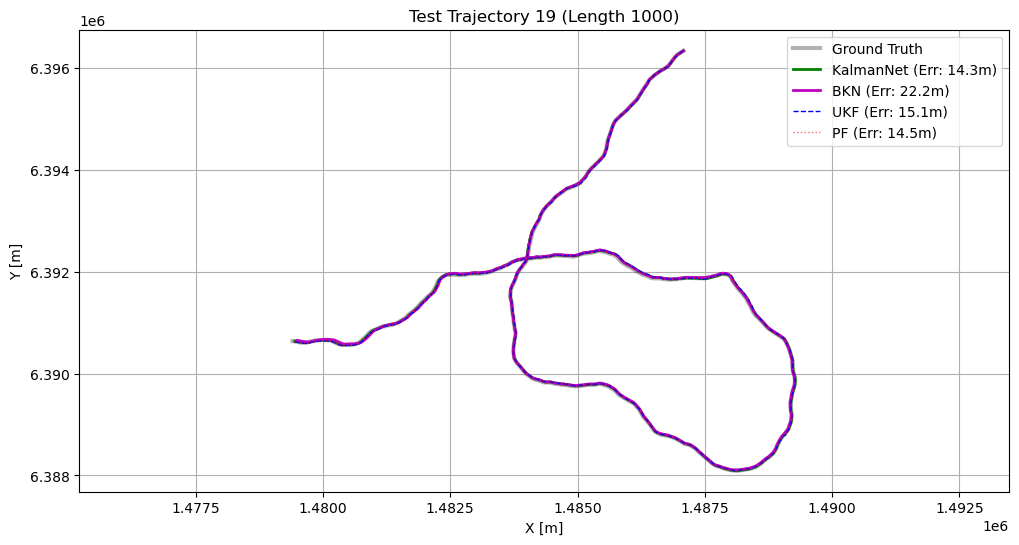

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.44it/s]t]


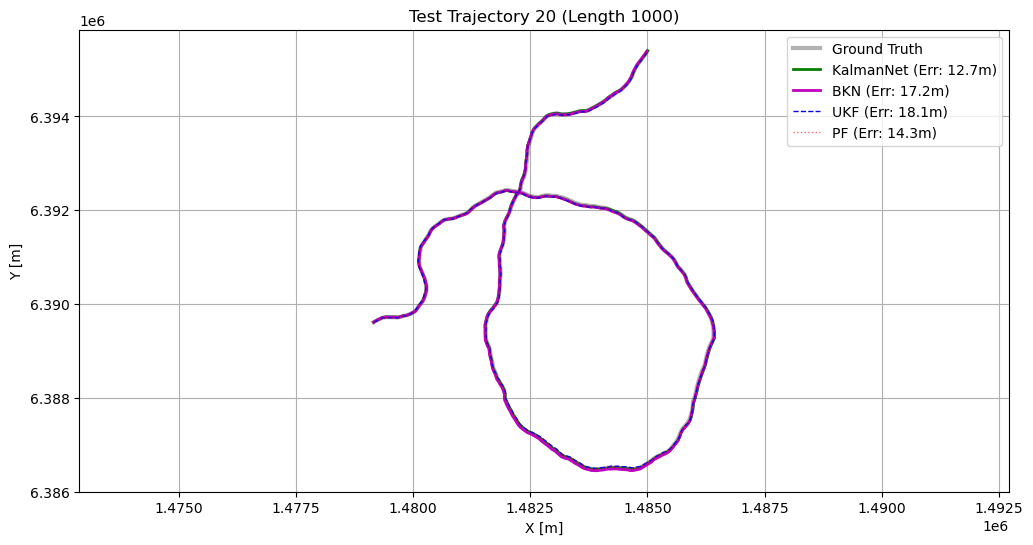

Evaluating trajectories: 100%|██████████| 20/20 [07:25<00:00, 22.25s/it]

    Run_ID  KNet_MSE  BKN_MSE  UKF_MSE  PF_MSE  KNet_PosErr  BKN_PosErr  \
0        1    588.67   642.61   684.75  649.06        21.43       24.06   
1        2    477.24   569.41   565.69  519.93        19.97       20.41   
2        3    435.65   880.03   806.89  623.04        18.88       25.90   
3        4    240.59   591.29   447.37  342.90        13.83       22.26   
4        5    601.77 2,015.49   309.99  347.15        21.53       41.05   
5        6    359.99   371.36   668.64  521.66        17.35       18.00   
6        7    460.18   619.78   632.56  420.69        19.99       23.11   
7        8    477.63   336.36   462.92  341.20        17.22       15.36   
8        9    280.35 1,203.62   390.87  406.72        14.77       32.18   
9       10    492.25   293.56   506.67  526.75        19.51       14.71   
10      11    303.99   753.91   316.96  346.37        14.48       23.76   
11      12    380.05   583.12   371.22  280.67        17.24       21.53   
12      13    385.21   99

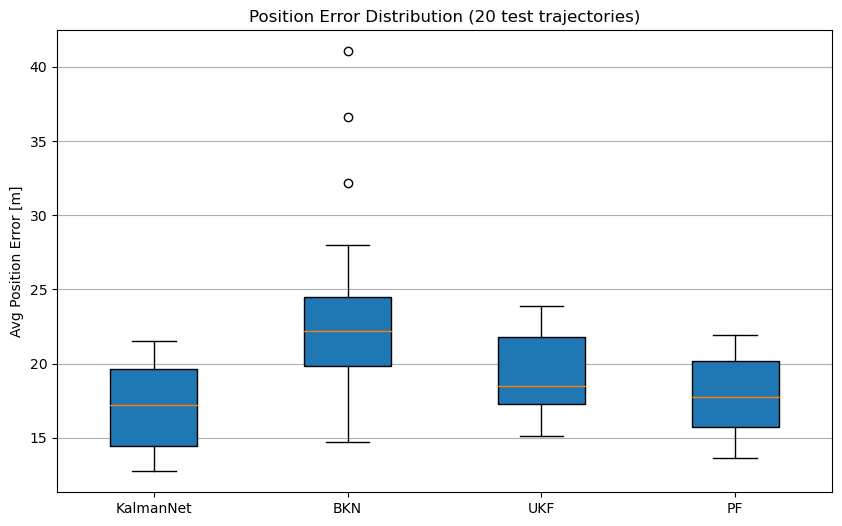


Original ANEES (averaged per-trajectory):
BKN             | 8.79 ± 1.37
UKF             | 6.95 ± 0.78
PF              | 7.33 ± 0.67


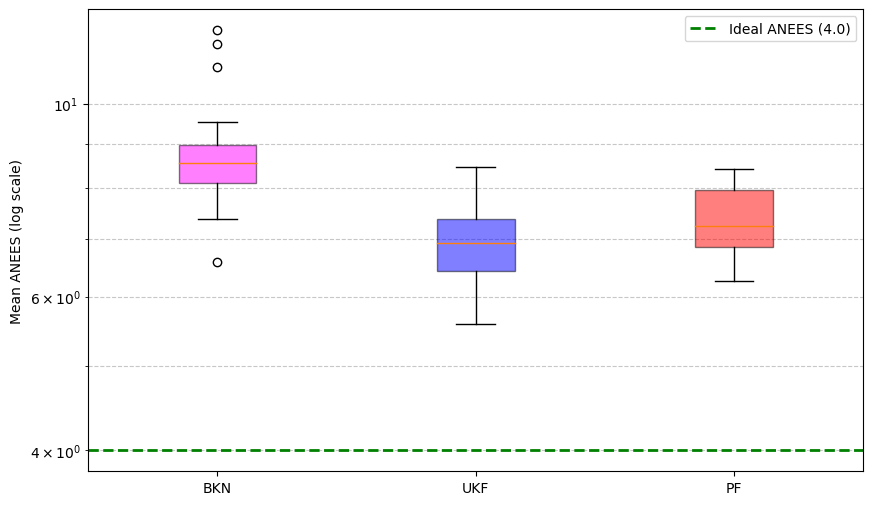


Calculating exact EEC and APEC metrics for all models...

COMPREHENSIVE UNCERTAINTY ANALYSIS (M=20 trajectories)
Ideal values: Volume Ratio = 1.0 | Linear Ratio = 1.0 | ANEES = 4.0
> 1.0 : Optimistic (underestimates error) | < 1.0 : Conservative (overestimates error)
-----------------------------------------------------------------------------------------------
Model                          | Absolute Volume Ratio     | Linear Ratio    | Classic ANEES  
-----------------------------------------------------------------------------------------------
UKF                            | 4.3301                    | 1.3707          | 6.9509         
Particle Filter                | 7.6416                    | 1.5801          | 7.3305         
Bayesian KNet (BKN)            | 4.5745                    | 1.2753          | 8.7910         


In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import Filters
import os
from tqdm import tqdm

# ==============================================================================
# 1. FUNCTIONS FOR CALCULATING GEOMETRIC AND CLASSICAL UNCERTAINTY METRICS
# ==============================================================================
def calculate_determinant_ratios_exact(x_true_list, x_hat_list, P_hat_list):
    """
    1:1 implementation of EEC and APEC metrics according to the mathematical definition.
    """
    if len(x_hat_list) == 0 or len(P_hat_list) == 0:
        return np.nan, np.nan

    min_len = min(
        min([x.shape[0] for x in x_true_list]),
        min([x.shape[0] for x in x_hat_list]),
        min([P.shape[0] for P in P_hat_list])
    )

    x_true = torch.stack([x[:min_len] for x in x_true_list]) # [M, N, n_x]
    x_hat = torch.stack([x[:min_len] for x in x_hat_list])   # [M, N, n_x]
    P_hat = torch.stack([P[:min_len] for P in P_hat_list])   # [M, N, n_x, n_x]

    M, N, n_x = x_true.shape
    error = x_hat - x_true
    
    # NOTE: Angle wrapping is disabled here because the state is [x, y, vx, vy].
    # If the state contained an angle (e.g., at index 2), uncomment the following block:
    # if n_x >= 3:
    #     angle_err = error[..., 2]
    #     angle_err = (angle_err + np.pi) % (2 * np.pi) - np.pi
    #     error[..., 2] = angle_err
    
    error_expanded = error.unsqueeze(-1)   # [M, N, n_x, 1]
    error_transposed = error.unsqueeze(-2) # [M, N, 1, n_x]
    
    EEC = (error_expanded @ error_transposed).mean(dim=0) # [N, n_x, n_x]
    APEC = P_hat.mean(dim=0) # [N, n_x, n_x]

    det_ratio_list = []
    det_ratio_linear_list = []

    for t in range(1, N):
        det_EEC = torch.linalg.det(EEC[t]).item()
        det_APEC = torch.linalg.det(APEC[t]).item()

        if det_APEC > 1e-12 and det_EEC >= 0:
            ratio = det_EEC / det_APEC
            det_ratio_list.append(ratio)
            det_ratio_linear_list.append(ratio ** (1.0 / n_x))

    if not det_ratio_list:
        return np.nan, np.nan

    return np.mean(det_ratio_list), np.mean(det_ratio_linear_list)


def calculate_exact_anees(x_true_list, x_hat_list, P_hat_list):
    """
    Exact ANEES logic calculating with pseudo-inverses.
    """
    if len(x_hat_list) == 0 or len(P_hat_list) == 0:
        return np.nan

    M = len(x_true_list)
    anees_per_trajectory = []

    for i in range(M):
        x_true = x_true_list[i]
        x_hat = x_hat_list[i]
        P_hat = P_hat_list[i]

        min_len = min(x_true.shape[0], x_hat.shape[0], P_hat.shape[0])
        x_true = x_true[:min_len]
        x_hat = x_hat[:min_len]
        P_hat = P_hat[:min_len]

        error = x_true - x_hat
        
        # Angle handling see above (disabled here for [x, y, vx, vy] model)
        
        nees_time = []
        for t in range(min_len):
            e_t = error[t].unsqueeze(1) 
            P_t = P_hat[t]              
            
            try:
                P_inv = torch.linalg.pinv(P_t, hermitian=True)
            except RuntimeError:
                P_inv = torch.eye(P_t.shape[0], device=P_t.device)
            
            nees = torch.mm(torch.mm(e_t.t(), P_inv), e_t).item()
            nees_time.append(nees)
            
        anees_per_trajectory.append(np.mean(nees_time))

    return np.mean(anees_per_trajectory)


# ==============================================================================
# 2. SETUP AND INITIALIZATION OF TESTING VARIABLES
# ==============================================================================
TEST_DATA_PATH = './generated_data_synthetic_controlled-extended-trajectories-harder/test_set/test.pt'
PLOT_PER_ITERATION = True  
MAX_TEST_SAMPLES = 20      
J_EVALUATION = 100           

# Make sure `device` is defined in your environment
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
test_data = torch.load(TEST_DATA_PATH, map_location=device)
X_test_all = test_data['x']  # Ground Truth [N, Seq, 4]
Y_test_all = test_data['y']  # Measurements [N, Seq, 3]

n_samples = min(X_test_all.shape[0], MAX_TEST_SAMPLES)

detailed_results = []
agg_mse = {"KNet": [], "UKF": [], "PF": [], "BKN": []}
agg_pos = {"KNet": [], "UKF": [], "PF": [], "BKN": []}
agg_anees = {"UKF": [], "PF": [], "BKN": []}

# Dictionary for collecting complete tensors across the whole test set for the new metric
trajectory_tensors = {
    'GT': [],
    'UKF': {'x': [], 'P': []},
    'PF':  {'x': [], 'P': []},
    'BKN': {'x': [], 'P': []}
}

state_knet2.eval()
state_bkn.eval()

def calculate_anees(gt, est, P):
    T = min(len(gt), len(est), len(P))
    anees_vals = []
    
    gt = gt[:T]
    est = est[:T]
    P = P[:T]
    
    for t in range(T):
        e_t = gt[t] - est[t] 
        P_t = P[t]
        
        try:
            if np.linalg.cond(P_t) > 1e10:
                P_t = P_t + np.eye(P_t.shape[0]) * 1e-6
                
            P_inv = np.linalg.inv(P_t)
            
            anees_t = e_t.T @ P_inv @ e_t
            anees_vals.append(anees_t)
        except np.linalg.LinAlgError:
            anees_vals.append(np.nan)
            
    return np.nanmean(anees_vals)


# ==============================================================================
# 3. MAIN EVALUATION LOOP
# ==============================================================================
for i in tqdm(range(n_samples), desc="Evaluating trajectories"):
    
    x_gt_tensor = X_test_all[i]      # [Seq, 4]
    y_obs_tensor = Y_test_all[i]     # [Seq, 3]
    
    x_gt = x_gt_tensor.cpu().numpy()
    seq_len = x_gt.shape[0]
    
    # Save GT to the new tracking list (as float32 CPU tensor)
    trajectory_tensors['GT'].append(x_gt_tensor.cpu().float())

    true_init_state = x_gt_tensor[0] # [4]
    
    # --- A) KNet ---
    with torch.no_grad():
        initial_state_batch = true_init_state.unsqueeze(0) # [1, 4]
        state_knet2.reset(batch_size=1, initial_state=initial_state_batch)
        
        knet_preds = []
        y_input_batch = y_obs_tensor.unsqueeze(0) # [1, Seq, 3]
        
        for t in range(1, seq_len):
            y_t = y_input_batch[:, t, :] # [1, 3]
            x_est = state_knet2.step(y_t)
            knet_preds.append(x_est)
            
        if len(knet_preds) > 0:
            knet_preds_tensor = torch.stack(knet_preds, dim=1) # [1, Seq-1, 4]
            full_knet_est = torch.cat([initial_state_batch.unsqueeze(1), knet_preds_tensor], dim=1)
        else:
            full_knet_est = initial_state_batch.unsqueeze(1)
            
        x_est_knet = full_knet_est.squeeze().cpu().numpy()

    # --- B) BKN (Ensemble) ---
    with torch.no_grad():
        init_batch = true_init_state.unsqueeze(0).repeat(J_EVALUATION, 1)
        state_bkn.reset(batch_size=J_EVALUATION, initial_state=init_batch)
        
        bkn_preds = []
        y_input_batch = y_obs_tensor.unsqueeze(0).repeat(J_EVALUATION, 1, 1)
        
        for t in range(1, seq_len):
            y_t = y_input_batch[:, t, :]
            x_est, _ = state_bkn.step(y_t) 
            bkn_preds.append(x_est)
            
        if len(bkn_preds) > 0:
            bkn_preds_tensor = torch.stack(bkn_preds, dim=1) # [J, Seq-1, 4]
            full_bkn_ensemble = torch.cat([init_batch.unsqueeze(1), bkn_preds_tensor], dim=1) # [J, Seq, 4]
            
            x_est_mean = full_bkn_ensemble.mean(dim=0)
            x_est_bkn = x_est_mean.cpu().numpy()
            
            residuals = full_bkn_ensemble - x_est_mean.unsqueeze(0) # [J, Seq, 4]
            residuals = residuals.permute(1, 2, 0) # [Seq, 4, J]
            P_bkn_tensor = torch.bmm(residuals, residuals.transpose(1, 2)) / (J_EVALUATION - 1)
            P_bkn = P_bkn_tensor.cpu().numpy()
            
        else:
            x_est_bkn = x_gt
            P_bkn = np.eye(4)[np.newaxis, :, :].repeat(len(x_gt), axis=0)

    # --- C) UKF ---
    ukf_ideal = Filters.UnscentedKalmanFilter(system_model)
    ukf_res = ukf_ideal.process_sequence(
        y_seq=y_obs_tensor,
        Ex0=true_init_state, 
        P0=system_model.P0
    )
    x_est_ukf = ukf_res['x_filtered'].cpu().numpy()
    P_ukf = ukf_res['P_filtered'].cpu().numpy() if isinstance(ukf_res.get('P_filtered'), torch.Tensor) else ukf_res.get('P_filtered', ukf_res.get('P'))
    
    # --- D) PF ---
    pf = Filters.VectorizedParticleFilter(system_model, num_particles=500281)#4372281
    pf_res = pf.process_sequence(
        y_seq=y_obs_tensor,
        Ex0=true_init_state, 
        P0=system_model.P0
    )
    x_est_pf = pf_res['x_filtered'].cpu().numpy()
    P_pf = pf_res['P_filtered'].cpu().numpy() if isinstance(pf_res.get('P_filtered'), torch.Tensor) else pf_res.get('P_filtered', pf_res.get('P'))
    
    # --- Data collection for exact matrix metrics from cell 1 ---
    trajectory_tensors['BKN']['x'].append(torch.tensor(x_est_bkn, dtype=torch.float32))
    trajectory_tensors['BKN']['P'].append(torch.tensor(P_bkn, dtype=torch.float32))
    trajectory_tensors['UKF']['x'].append(torch.tensor(x_est_ukf, dtype=torch.float32))
    trajectory_tensors['UKF']['P'].append(torch.tensor(P_ukf, dtype=torch.float32))
    trajectory_tensors['PF']['x'].append(torch.tensor(x_est_pf, dtype=torch.float32))
    trajectory_tensors['PF']['P'].append(torch.tensor(P_pf, dtype=torch.float32))

    # --- Calculation of original per-trajectory statistics ---
    min_len = min(len(x_gt), len(x_est_knet), len(x_est_ukf))
    
    diff_knet = x_est_knet[:min_len] - x_gt[:min_len]
    mse_knet = np.mean(np.sum(diff_knet[:, :2]**2, axis=1))
    pos_err_knet = np.mean(np.sqrt(diff_knet[:, 0]**2 + diff_knet[:, 1]**2))
    
    diff_bkn = x_est_bkn[:min_len] - x_gt[:min_len]
    mse_bkn = np.mean(np.sum(diff_bkn[:, :2]**2, axis=1))
    pos_err_bkn = np.mean(np.sqrt(diff_bkn[:, 0]**2 + diff_bkn[:, 1]**2))
    anees_bkn = calculate_anees(x_gt[:min_len], x_est_bkn[:min_len], P_bkn[:min_len])
    
    diff_ukf = x_est_ukf[:min_len] - x_gt[:min_len]
    mse_ukf = np.mean(np.sum(diff_ukf[:, :2]**2, axis=1))
    pos_err_ukf = np.mean(np.sqrt(diff_ukf[:, 0]**2 + diff_ukf[:, 1]**2))
    anees_ukf = calculate_anees(x_gt[:min_len], x_est_ukf[:min_len], P_ukf[:min_len])
    
    diff_pf = x_est_pf[:min_len] - x_gt[:min_len]
    mse_pf = np.mean(np.sum(diff_pf[:, :2]**2, axis=1))
    pos_err_pf = np.mean(np.sqrt(diff_pf[:, 0]**2 + diff_pf[:, 1]**2))
    anees_pf = calculate_anees(x_gt[:min_len], x_est_pf[:min_len], P_pf[:min_len])
    
    agg_mse["KNet"].append(mse_knet)
    agg_pos["KNet"].append(pos_err_knet)
    agg_mse["BKN"].append(mse_bkn)
    agg_pos["BKN"].append(pos_err_bkn)
    agg_mse["UKF"].append(mse_ukf)
    agg_pos["UKF"].append(pos_err_ukf)
    agg_mse["PF"].append(mse_pf)
    agg_pos["PF"].append(pos_err_pf)

    agg_anees["BKN"].append(anees_bkn)
    agg_anees["UKF"].append(anees_ukf)
    agg_anees["PF"].append(anees_pf)

    detailed_results.append({
        "Run_ID": i + 1,
        "KNet_MSE": mse_knet,
        "BKN_MSE": mse_bkn,
        "UKF_MSE": mse_ukf,
        "PF_MSE": mse_pf,
        "KNet_PosErr": pos_err_knet,
        "BKN_PosErr": pos_err_bkn,
        "UKF_PosErr": pos_err_ukf,
        "PF_PosErr": pos_err_pf
    })
    
    # Trajectory plotting
    if PLOT_PER_ITERATION or (i == n_samples - 1):
        fig = plt.figure(figsize=(12, 6))
        plt.plot(x_gt[:, 0], x_gt[:, 1], 'k-', linewidth=3, alpha=0.3, label='Ground Truth')
        plt.plot(x_est_knet[:, 0], x_est_knet[:, 1], 'g-', linewidth=2, label=f'KalmanNet (Err: {pos_err_knet:.1f}m)')
        plt.plot(x_est_bkn[:, 0], x_est_bkn[:, 1], 'm-', linewidth=2, label=f'BKN (Err: {pos_err_bkn:.1f}m)')
        plt.plot(x_est_ukf[:, 0], x_est_ukf[:, 1], 'b--', linewidth=1, label=f'UKF (Err: {pos_err_ukf:.1f}m)')
        plt.plot(x_est_pf[:, 0], x_est_pf[:, 1], 'r:', linewidth=1, alpha=0.6, label=f'PF (Err: {pos_err_pf:.1f}m)')
        
        plt.title(f"Test Trajectory {i+1} (Length {seq_len})")
        plt.xlabel("X [m]")
        plt.ylabel("Y [m]")
        plt.legend()
        plt.axis('equal')
        plt.grid(True)
        plt.show()

# ==============================================================================
# 4. ORIGINAL OUTPUTS AND TABLES (ACCURACY AND CLASSIC ANEES)
# ==============================================================================
df_results = pd.DataFrame(detailed_results)
pd.options.display.float_format = '{:,.2f}'.format
print(df_results[["Run_ID", "KNet_MSE", "BKN_MSE", "UKF_MSE", "PF_MSE", "KNet_PosErr", "BKN_PosErr", "UKF_PosErr", "PF_PosErr"]])

def get_stats(key):
    return np.mean(agg_mse[key]), np.std(agg_mse[key]), np.mean(agg_pos[key]), np.std(agg_pos[key])

knet_stats = get_stats("KNet")
bkn_stats = get_stats("BKN")
ukf_stats = get_stats("UKF")
pf_stats = get_stats("PF")

print(f"\n{'Model':<15} | {'MSE (Mean ± Std)':<25} | {'Pos Error (Mean ± Std)':<25}")
print("-" * 75)
print(f"{'KalmanNet':<15} | {knet_stats[0]:.1f} ± {knet_stats[1]:.1f} | {knet_stats[2]:.2f} ± {knet_stats[3]:.2f} m")
print(f"{'BKN':<15} | {bkn_stats[0]:.1f} ± {bkn_stats[1]:.1f} | {bkn_stats[2]:.2f} ± {bkn_stats[3]:.2f} m")
print(f"{'UKF':<15} | {ukf_stats[0]:.1f} ± {ukf_stats[1]:.1f} | {ukf_stats[2]:.2f} ± {ukf_stats[3]:.2f} m")
print(f"{'PF':<15}  | {pf_stats[0]:.1f} ± {pf_stats[1]:.1f} | {pf_stats[2]:.2f} ± {pf_stats[3]:.2f} m")
print("="*75)

plt.figure(figsize=(10, 6))
plt.boxplot([agg_pos["KNet"], agg_pos["BKN"], agg_pos["UKF"], agg_pos["PF"]], labels=['KalmanNet', 'BKN', 'UKF', 'PF'], patch_artist=True)
plt.title(f"Position Error Distribution ({n_samples} test trajectories)")
plt.ylabel("Avg Position Error [m]")
plt.grid(True, axis='y')
plt.show()

EXPECTED_ANEES = 4.0 
filters_anees = ["BKN", "UKF", "PF"]

mean_anees = {f: np.nanmean(agg_anees[f]) for f in filters_anees}
std_anees = {f: np.nanstd(agg_anees[f]) for f in filters_anees}

print(f"\nOriginal ANEES (averaged per-trajectory):")
for f in filters_anees:
    print(f"{f:<15} | {mean_anees[f]:.2f} ± {std_anees[f]:.2f}")
print("="*80)

plt.figure(figsize=(10, 6))
data_to_plot = [agg_anees[f] for f in filters_anees]

box = plt.boxplot(data_to_plot, labels=filters_anees, patch_artist=True)

colors = ['magenta', 'blue', 'red']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

plt.axhline(y=EXPECTED_ANEES, color='green', linestyle='--', linewidth=2, 
            label=f'Ideal ANEES ({EXPECTED_ANEES})')
plt.ylabel("Mean ANEES (log scale)")
plt.yscale('log')
plt.legend()
plt.grid(True, axis='y', which='both', linestyle='--', alpha=0.7)
plt.show()

# ==============================================================================
# 5. COMPREHENSIVE UNCERTAINTY ANALYSIS (EEC, APEC)
# ==============================================================================
print("\nCalculating exact EEC and APEC metrics for all models...")

x_true_list = trajectory_tensors['GT']
M = len(x_true_list)
n_x = x_true_list[0].shape[1]

models_map = {
    'UKF': "UKF",
    'PF':  "Particle Filter",
    'BKN': "Bayesian KNet (BKN)"
}

results_exact = {}

for model_key, model_name in models_map.items():
    if model_key not in trajectory_tensors:
        continue
        
    x_hat_list = trajectory_tensors[model_key]['x']
    P_hat_list = trajectory_tensors[model_key]['P']
    
    if len(P_hat_list) != M:
        results_exact[model_name] = (np.nan, np.nan, np.nan)
        continue

    abs_ratio, lin_ratio = calculate_determinant_ratios_exact(x_true_list, x_hat_list, P_hat_list)
    anees_val = calculate_exact_anees(x_true_list, x_hat_list, P_hat_list)
    results_exact[model_name] = (abs_ratio, lin_ratio, anees_val)

print("\n" + "="*95)
print(f"COMPREHENSIVE UNCERTAINTY ANALYSIS (M={M} trajectories)")
print("="*95)
print(f"Ideal values: Volume Ratio = 1.0 | Linear Ratio = 1.0 | ANEES = {float(n_x)}")
print(f"> 1.0 : Optimistic (underestimates error) | < 1.0 : Conservative (overestimates error)")
print("-" * 95)
print(f"{'Model':<30} | {'Absolute Volume Ratio':<25} | {'Linear Ratio':<15} | {'Classic ANEES':<15}")
print("-" * 95)

for model_name, (abs_ratio, lin_ratio, anees_val) in results_exact.items():
    if np.isnan(abs_ratio) and np.isnan(anees_val):
        print(f"{model_name:<30} | {'Unavailable covariance P':<25} | {'-':<15} | {'-':<15}")
    else:
        print(f"{model_name:<30} | {abs_ratio:<25.4f} | {lin_ratio:<15.4f} | {anees_val:<15.4f}")
print("="*95)

## Graphs for thesis

Processing PF (GPU): 100%|██████████| 999/999 [00:17<00:00, 57.56it/s]


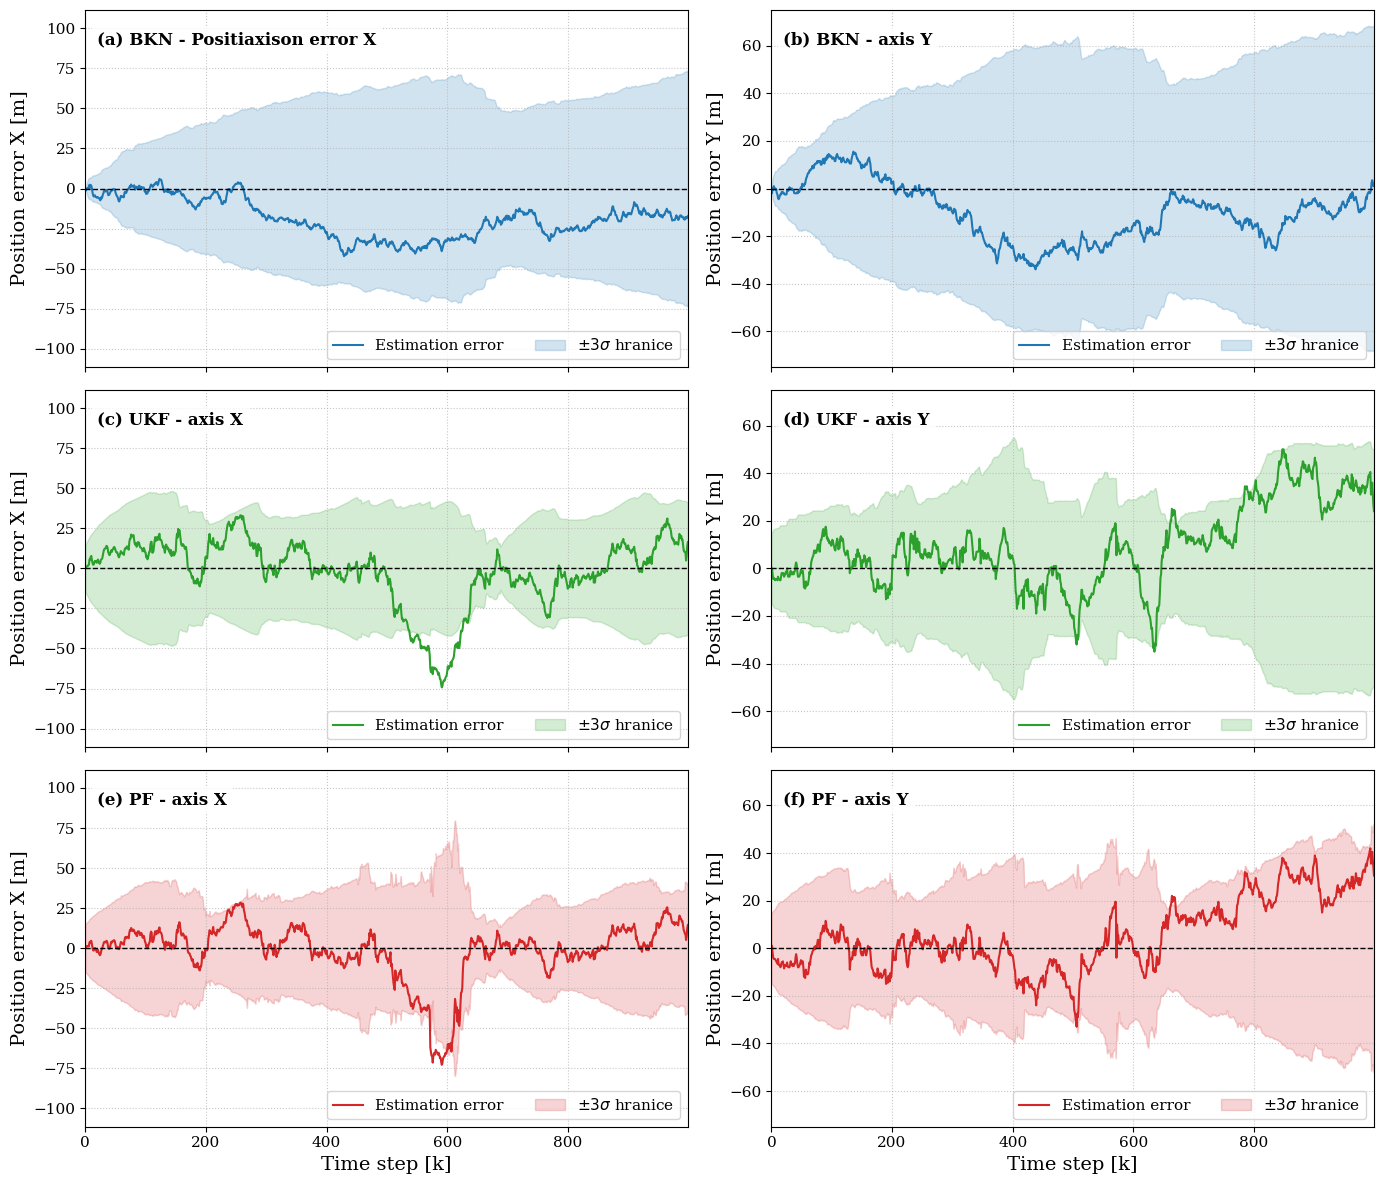

BKN - axis X    |  99.90 % 3-sigma border
UKF - axis X    |  91.00 % 3-sigma border
PF  - axis X    |  96.80 % 3-sigma border
----------------------------------------
BKN - axis Y    | 100.00 % 3-sigma border
UKF - axis Y    |  98.00 % 3-sigma border
PF  - axis Y    |  98.90 % 3-sigma border


In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import Filters 

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.labelsize': 14,
    'legend.fontsize': 11,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'lines.linewidth': 1.5
})

TRAJ_IDX = 2
ZOOM_SLICE = slice(0, None) 

x_gt_tensor = X_test_all[TRAJ_IDX].to(device)
y_obs_tensor = Y_test_all[TRAJ_IDX].to(device)

x_gt = x_gt_tensor.cpu().numpy()
seq_len = x_gt.shape[0]

true_init_state_safe = x_gt_tensor[0].clone() 
y_obs_safe = y_obs_tensor.clone()


if torch.is_tensor(system_model.P0):
    P0_safe = system_model.P0.clone()
else:
    P0_safe = system_model.P0.copy()

time_steps = np.arange(seq_len)


state_bkn.eval()
with torch.no_grad():
    init_batch = true_init_state_safe.unsqueeze(0).repeat(J_EVALUATION, 1)
    y_input_batch = y_obs_safe.unsqueeze(0).repeat(J_EVALUATION, 1, 1)
    state_bkn.reset(batch_size=J_EVALUATION, initial_state=init_batch)
    
    bkn_preds_steps = []
    for t in range(1, seq_len):
        x_est, _ = state_bkn.step(y_input_batch[:, t, :])
        bkn_preds_steps.append(x_est)
    
    if len(bkn_preds_steps) > 0:
        preds_tensor = torch.stack(bkn_preds_steps, dim=1)
        full_ensemble = torch.cat([init_batch.unsqueeze(1), preds_tensor], dim=1)
        
        # Mean & Covariance
        bkn_mean = full_ensemble.mean(dim=0).cpu().numpy()
        residuals = full_ensemble - full_ensemble.mean(dim=0).unsqueeze(0)
        
        res_perm_T = residuals.permute(1, 2, 0)
        res_perm = residuals.permute(1, 0, 2)
        P_bkn_tensor = torch.bmm(res_perm_T, res_perm) / (J_EVALUATION - 1)

        P_bkn_tensor = P_bkn_tensor + torch.eye(4, device=device).unsqueeze(0) * 1e-6 
        bkn_P = P_bkn_tensor.cpu().numpy()
    else:
        bkn_mean = x_gt
        bkn_P = np.zeros((seq_len, 4, 4))


ukf_ideal = Filters.UnscentedKalmanFilter(system_model)

ukf_res = ukf_ideal.process_sequence(
    y_seq=y_obs_safe.clone(), 
    Ex0=true_init_state_safe.clone(), 
    P0=P0_safe.clone() if torch.is_tensor(P0_safe) else P0_safe.copy()
)

ukf_mean = ukf_res['x_filtered'].cpu().numpy()
ukf_P_tensor = ukf_res.get('P_filtered', ukf_res.get('P', None))
if ukf_P_tensor is not None:
    ukf_P = ukf_P_tensor.cpu().numpy()
else:
    ukf_P = np.zeros((seq_len, 4, 4))

pf = Filters.VectorizedParticleFilter(system_model, num_particles=500000)
pf_res = pf.process_sequence(
    y_seq=y_obs_safe.clone(),
    Ex0=true_init_state_safe.clone(), 
    P0=P0_safe.clone() if torch.is_tensor(P0_safe) else P0_safe.copy()
)

pf_mean = pf_res['x_filtered'].cpu().numpy()
pf_P_tensor = pf_res.get('P_filtered', pf_res.get('P', None))
if pf_P_tensor is not None:
    pf_P = pf_P_tensor.cpu().numpy()
else:
    pf_P = np.zeros((seq_len, 4, 4))

def get_stats(mean, P, gt):
    err = mean - gt
    sigma_x = np.sqrt(P[:, 0, 0])
    sigma_y = np.sqrt(P[:, 1, 1])
    return err[:, 0], err[:, 1], sigma_x, sigma_y

bkn_err_x, bkn_err_y, bkn_sig_x, bkn_sig_y = get_stats(bkn_mean, bkn_P, x_gt)
ukf_err_x, ukf_err_y, ukf_sig_x, ukf_sig_y = get_stats(ukf_mean, ukf_P, x_gt)
pf_err_x, pf_err_y, pf_sig_x, pf_sig_y = get_stats(pf_mean, pf_P, x_gt)

fig, axes = plt.subplots(3, 2, figsize=(14, 12), sharex=True)

y_limit_x = max(np.max(np.abs(bkn_err_x)), np.max(np.abs(ukf_err_x)), np.max(np.abs(pf_err_x))) * 1.5
y_limit_y = max(np.max(np.abs(bkn_err_y)), np.max(np.abs(ukf_err_y)), np.max(np.abs(pf_err_y))) * 1.5

def plot_subplot(ax, err, sig, label_title, line_color, is_y_axis=False, show_xlabel=False):
    ax.plot(time_steps[ZOOM_SLICE], err[ZOOM_SLICE], label='Estimation error', color=line_color, linewidth=1.5)
    ax.fill_between(time_steps[ZOOM_SLICE], 3 * sig[ZOOM_SLICE], -3 * sig[ZOOM_SLICE], 
                    color=line_color, alpha=0.2, label=r'$\pm 3\sigma$ hranice')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    
    ax.text(0.02, 0.94, label_title, transform=ax.transAxes, 
             fontsize=12, fontweight='bold', va='top', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
    
    ax.grid(True, linestyle=':', alpha=0.7)
    
    if is_y_axis:
        ax.set_ylim(-y_limit_y, y_limit_y)
    else:
        ax.set_ylim(-y_limit_x, y_limit_x)
        
    ax.set_xlim(0, seq_len - 1)
    
    if show_xlabel:
        ax.set_xlabel("Time step [k]")

plot_subplot(axes[0, 0], bkn_err_x, bkn_sig_x, '(a) BKN - Positiaxison error X', '#1f77b4', is_y_axis=False)
axes[0, 0].set_ylabel("Position error X [m]")
axes[0, 0].legend(loc='lower right', ncol=2)

plot_subplot(axes[0, 1], bkn_err_y, bkn_sig_y, '(b) BKN - axis Y', '#1f77b4', is_y_axis=True)
axes[0, 1].set_ylabel("Position error Y [m]")
axes[0, 1].legend(loc='lower right', ncol=2)

# --- Prostřední řádek: UKF ---
plot_subplot(axes[1, 0], ukf_err_x, ukf_sig_x, '(c) UKF - axis X', '#2ca02c', is_y_axis=False)
axes[1, 0].set_ylabel("Position error X [m]")
axes[1, 0].legend(loc='lower right', ncol=2)

plot_subplot(axes[1, 1], ukf_err_y, ukf_sig_y, '(d) UKF - axis Y', '#2ca02c', is_y_axis=True)
axes[1, 1].set_ylabel("Position error Y [m]")
axes[1, 1].legend(loc='lower right', ncol=2)

plot_subplot(axes[2, 0], pf_err_x, pf_sig_x, '(e) PF - axis X', '#d62728', is_y_axis=False, show_xlabel=True)
axes[2, 0].set_ylabel("Position error X [m]")
axes[2, 0].legend(loc='lower right', ncol=2)

plot_subplot(axes[2, 1], pf_err_y, pf_sig_y, '(f) PF - axis Y', '#d62728', is_y_axis=True, show_xlabel=True)
axes[2, 1].set_ylabel("Position error Y [m]")
axes[2, 1].legend(loc='lower right', ncol=2)

plt.tight_layout()


# os.makedirs("TAN_graphs", exist_ok=True)
# pdf_path = f"TAN_graphs/Uncertainty_Comparison_Traj{TRAJ_IDX}.pdf"
# plt.savefig(pdf_path, format='pdf', bbox_inches='tight')

plt.show()

def print_cov(name, err, sig):
    inside = np.sum((err >= -3*sig) & (err <= 3*sig)) / len(err) * 100
    print(f"{name:<15} | {inside:>6.2f} % 3-sigma border")

print_cov("BKN - axis X", bkn_err_x, bkn_sig_x)
print_cov("UKF - axis X", ukf_err_x, ukf_sig_x)
print_cov("PF  - axis X", pf_err_x, pf_sig_x)
print("-" * 40)
print_cov("BKN - axis Y", bkn_err_y, bkn_sig_y)
print_cov("UKF - axis Y", ukf_err_y, ukf_sig_y)
print_cov("PF  - axis Y", pf_err_y, pf_sig_y)
print("=" * 40)